# K Nearest Neighbours (KNN)

We will build a simple KNN classifier on trading data (SPY). The goal is to predict next-day direction using lagged returns.


## Import Data

We load SPY via `yfinance`. If that is unavailable, we read from `../data/SPY.csv`.


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


path = '../data/'                      
df = pd.read_csv(path + 'SPY.csv', index_col=0)
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2018-12-31,2498.939941,2509.239990,2482.820068,2506.850098,3442870000
2019-01-02,2476.959961,2519.489990,2467.469971,2510.030029,3733160000
2019-01-03,2491.919922,2493.139893,2443.959961,2447.889893,3822860000
2019-01-04,2474.330078,2538.070068,2474.330078,2531.939941,4213410000
2019-01-07,2535.610107,2566.159912,2524.560059,2549.689941,4104710000


## Dependent and Independent Variables

We define lagged returns as features and a binary target (1 if today's return > 0 else 0). We keep the last 20% for testing to respect time order.


In [2]:
# Feature engineering
df['return'] = df['Close'].pct_change()
df['1_day_lag_returns'] = df['return'].shift(1)
df['2_day_lag_returns'] = df['return'].shift(2)
df['target'] = (df['return'] > 0).astype(int)
df = df.dropna()

We now define our X and y. We have two features and and our target coulmn. We split the data into train and test sets.

In [3]:
features = ['1_day_lag_returns', '2_day_lag_returns']
X = df[features]
y = df['target']

# Last 20% as test
test_frac = 0.20
split = int(len(df) * (1 - test_frac))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print('X_train:', X_train.shape, 'X_test:', X_test.shape)


X_train: (318, 2) X_test: (80, 2)


<a id='model'></a>

## KNN Classification Model
We will use `KNeighborsClassifier` from `sklearn.neighbors`.


In [4]:
# Create and fit the model
knn = KNeighborsClassifier()  # default k=5
knn.fit(X_train, y_train)

KNeighborsClassifier()

<a id='predict'></a>

## Predict & Evaluate
We predict on the test set, report test accuracy and the confusion matrix.


In [5]:
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print('Test accuracy:', round(acc, 4))
print('Confusion matrix (rows=true, cols=pred):\n', cm)

Test accuracy: 0.4875
Confusion matrix (rows=true, cols=pred):
 [[12 18]
 [23 27]]


<a id='plot'></a>

## Decision Regions 
A simple 2D plot showing predicted regions for class 0 and 1 over the lagged-return space with test points overlaid.


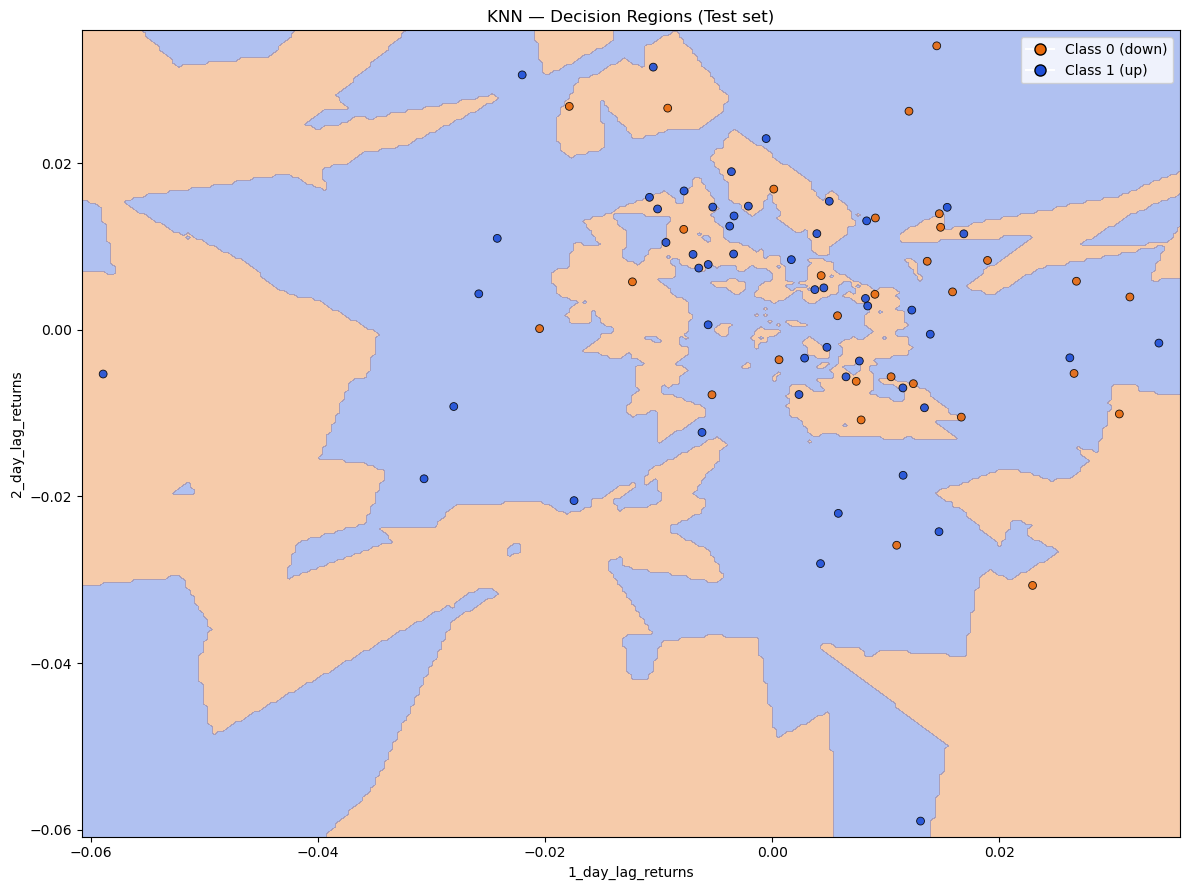

In [11]:
# Vibrant but readable (binary) palettes
cmap_light = ListedColormap(['#FFE4C7', '#CFE8FF'])   # soft orange / soft blue (background)
cmap_bold  = ListedColormap(['#E86A0C', '#1E4FD7'])   # vibrant orange / deep blue (points)

# Use the test window’s full range (plus a tiny padding)
f1, f2 = features[0], features[1]
x1_lo, x1_hi = X_test[f1].min(), X_test[f1].max()
x2_lo, x2_hi = X_test[f2].min(), X_test[f2].max()
pad1 = 0.02*(x1_hi - x1_lo) or 1e-6
pad2 = 0.02*(x2_hi - x2_lo) or 1e-6
x1_lo, x1_hi = x1_lo - pad1, x1_hi + pad1
x2_lo, x2_hi = x2_lo - pad2, x2_hi + pad2

# Grid and predictions
xx, yy = np.meshgrid(
    np.linspace(x1_lo, x1_hi, 250),
    np.linspace(x2_lo, x2_hi, 250)
)
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot
plt.figure(figsize=(12, 9))
# Background regions for classes {0,1}
plt.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], cmap=cmap_bold, alpha=0.35)

# Test points colored by true class {0,1}
plt.scatter(
    X_test[f1], X_test[f2],
    c=y_test.to_numpy(), cmap=cmap_bold, vmin=0, vmax=1,
    s=32, edgecolor='k', linewidth=0.6, alpha=0.9, zorder=2
)

# Legend (true classes)
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='Class 0 (down)',
           markerfacecolor=cmap_bold(0), markeredgecolor='k', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Class 1 (up)',
           markerfacecolor=cmap_bold(1), markeredgecolor='k', markersize=8),
]
plt.legend(handles=legend_handles, loc='upper right', frameon=True)

plt.xlabel(f1)
plt.ylabel(f2)
plt.title('KNN — Decision Regions (Test set)')
plt.xlim(x1_lo, x1_hi)
plt.ylim(x2_lo, x2_hi)
plt.tight_layout()
plt.show()


## Interpreting the decision-region plot

- **Axes:** `1_day_lag_returns` (x) vs `2_day_lag_returns` (y).
- **Background colors:** Model’s predicted class in each area (0 = down, 1 = up).  
  The boundary between colors is where the model is undecided.
- **Dots:** Test-set days, colored by the **true** class.  
  A dot inside its own class region = correct; in the other region = error.
- **Confidence intuition:** Points farther from the boundary are typically more confident; near the line are uncertain.
- **Why the patchy regions?** KNN bases decisions on nearby points, so shapes can look “island-like” rather than a straight line.
